# Создает файл с указанием использованных библиотек

In [3]:
!pip freeze > requirements.txt

# Обучение

c:\Users\PC2\Desktop\Klukin\Epikriz_2\Epikriz_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Начало обучения модели...
Обучение завершено!
Модель и объекты предобработки сохранены!
Точность на тестовой выборке: 0.8408


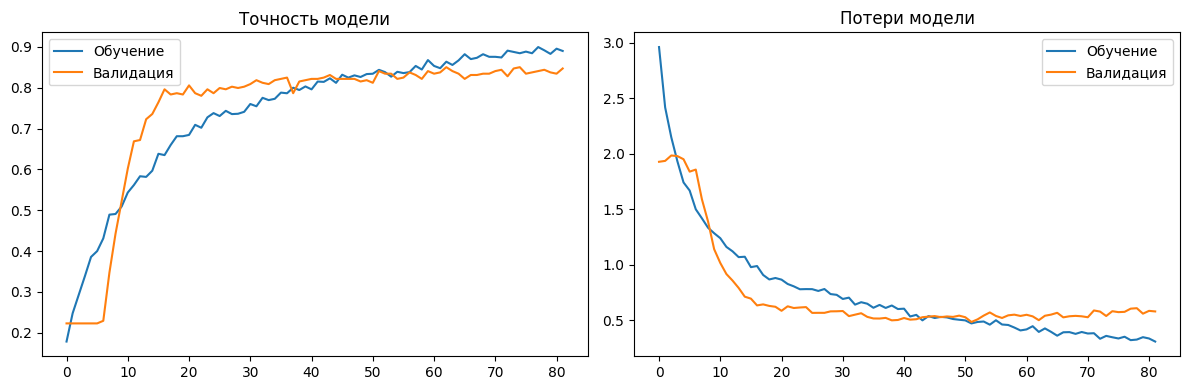

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ====== Загрузка данных ======
df = pd.read_csv('../../parsing/top7_merged_diagnoses.csv')
df.fillna(0, inplace=True)

exclude_columns = ['filename', 'diagnosis_code', 'diagnosis_name']
feature_columns = [col for col in df.columns if col not in exclude_columns]

X = df[feature_columns].values
y = df['diagnosis_code'].values

# ====== Кодирование и нормализация ======
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# ====== Разделение на выборки ======
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

# ====== Создание модели ======
def create_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(64, 3, activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))

    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))

    model.add(Conv1D(256, 3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))

    model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = create_cnn_lstm_model(input_shape, num_classes)

# ====== Callbacks ======
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, min_lr=1e-5),
    ModelCheckpoint('best_cnn_lstm_model.keras', monitor='val_accuracy', save_best_only=True)
]

# ====== Обучение ======
print("Начало обучения модели...")
history = model.fit(
    X_train, y_train_categorical,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test_categorical),
    callbacks=callbacks,
    verbose=0
)
print("Обучение завершено!")

# ====== Сохранение ======
model.save('medical_epicrisis_cnn_lstm_model.keras')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Модель и объекты предобработки сохранены!")

# ====== Оценка ======
test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

# ====== Графики ======
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучение')
plt.plot(history.history['val_accuracy'], label='Валидация')
plt.title('Точность модели')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучение')
plt.plot(history.history['val_loss'], label='Валидация')
plt.title('Потери модели')
plt.legend()
plt.tight_layout()
plt.show()


# Предсказание

Загрузка модели и preprocessing объектов...

Размерность данных: (1932, 45)

Диагнозы в наборе:
diagnosis_code
C34-C35    350
J44-J45    324
A15-A16    221
J45-J46    214
D14-D15    185
U07-U8     180
J15-J16     95
A16-A17     84
J18-J19     84
J12-J13     51
J41-J42     50
D86-D87     36
I27-I28     23
I26-I27     23
J20-J21     12
Name: count, dtype: int64

⚠️ Обнаружены новые диагнозы, отсутствующие при обучении: {'J12-J13', 'D86-D87', 'A16-A17', 'I27-I28', 'J20-J21', 'J18-J19', 'J41-J42', 'I26-I27'}
Оставлено 1569 записей после удаления неизвестных диагнозов.

Количество классов: 7
Размерность признаков: (1569, 42)

Начало предсказания...

Отчет по классификации:

              precision    recall  f1-score   support

     A15-A16       0.93      0.94      0.94       221
     C34-C35       0.98      0.93      0.95       350
     D14-D15       0.88      0.95      0.91       185
     J15-J16       0.78      0.56      0.65        95
     J44-J45       0.87      0.89      0.88       3

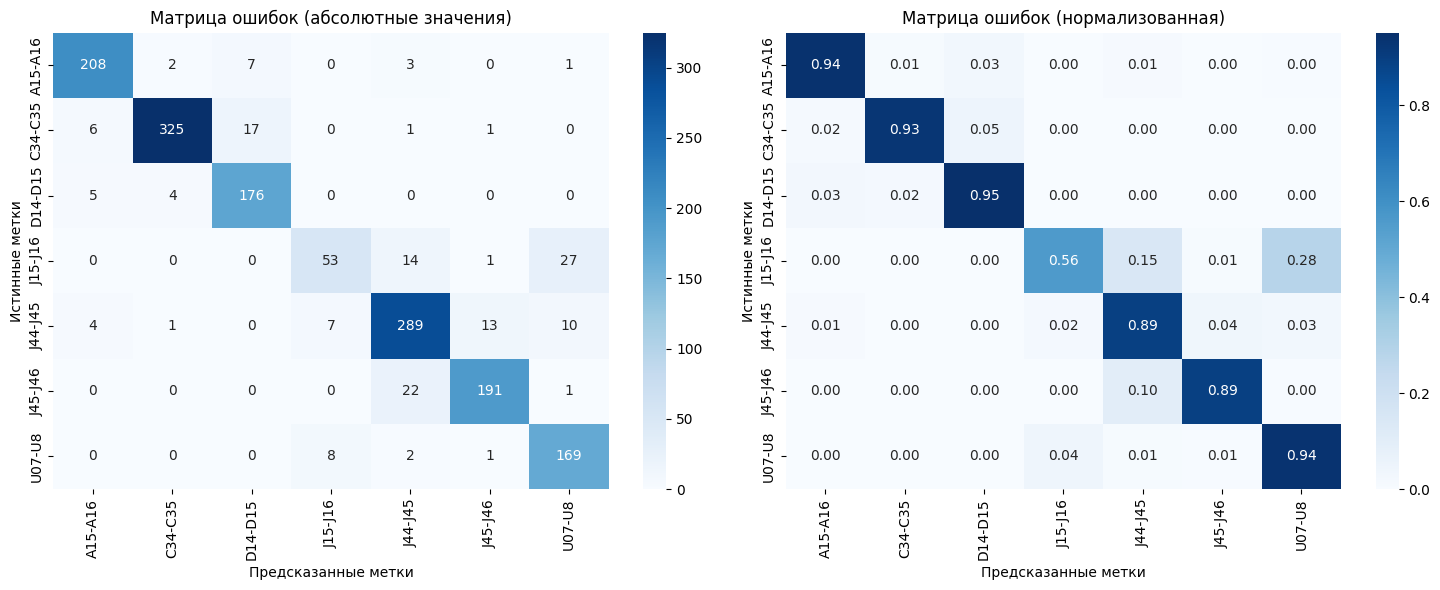


АНАЛИЗ МАТРИЦЫ ОШИБОК:

Точность по классам:
A15-A16: 94.1% (208/221)
C34-C35: 92.9% (325/350)
D14-D15: 95.1% (176/185)
J15-J16: 55.8% (53/95)
J44-J45: 89.2% (289/324)
J45-J46: 89.3% (191/214)
U07-U8: 93.9% (169/180)

Основные ошибки классификации:
  A15-A16 → C34-C35: 2 случаев (0.9%)
  A15-A16 → D14-D15: 7 случаев (3.2%)
  A15-A16 → J44-J45: 3 случаев (1.4%)
  A15-A16 → U07-U8: 1 случаев (0.5%)
  C34-C35 → A15-A16: 6 случаев (1.7%)
  C34-C35 → D14-D15: 17 случаев (4.9%)
  C34-C35 → J44-J45: 1 случаев (0.3%)
  C34-C35 → J45-J46: 1 случаев (0.3%)
  D14-D15 → A15-A16: 5 случаев (2.7%)
  D14-D15 → C34-C35: 4 случаев (2.2%)
  J15-J16 → J44-J45: 14 случаев (14.7%)
  J15-J16 → J45-J46: 1 случаев (1.1%)
  J15-J16 → U07-U8: 27 случаев (28.4%)
  J44-J45 → A15-A16: 4 случаев (1.2%)
  J44-J45 → C34-C35: 1 случаев (0.3%)
  J44-J45 → J15-J16: 7 случаев (2.2%)
  J44-J45 → J45-J46: 13 случаев (4.0%)
  J44-J45 → U07-U8: 10 случаев (3.1%)
  J45-J46 → J44-J45: 22 случаев (10.3%)
  J45-J46 → U07-U8: 1 

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ==========================
# Загрузка модели и объектов
# ==========================
print("Загрузка модели и preprocessing объектов...\n")

model = tf.keras.models.load_model('medical_epicrisis_cnn_lstm_model.keras')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# ==========================
# Загрузка новых данных
# ==========================
df = pd.read_csv('../../parsing/top20_merged_diagnoses.csv')
print("Размерность данных:", df.shape)
print("\nДиагнозы в наборе:")
print(df['diagnosis_code'].value_counts())

df.fillna(0, inplace=True)

# ==========================
# Проверка и фильтрация новых диагнозов
# ==========================
unknown_labels = set(df['diagnosis_code']) - set(label_encoder.classes_)
if unknown_labels:
    print(f"\n⚠️ Обнаружены новые диагнозы, отсутствующие при обучении: {unknown_labels}")
    df = df[~df['diagnosis_code'].isin(unknown_labels)]
    print(f"Оставлено {len(df)} записей после удаления неизвестных диагнозов.\n")

if df.empty:
    raise ValueError("Нет известных диагнозов для предсказания. Проверьте данные.")

# ==========================
# Предобработка данных
# ==========================
X = df[feature_columns].values
y = df['diagnosis_code'].values

y_encoded = label_encoder.transform(y)
num_classes = len(label_encoder.classes_)

X_scaled = scaler.transform(X)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(f"Количество классов: {num_classes}")
print(f"Размерность признаков: {X.shape}")
print("\nНачало предсказания...\n")

# ==========================
# Предсказание
# ==========================
y_pred = model.predict(X_reshaped, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# ==========================
# Отчёт по классификации
# ==========================
print("Отчет по классификации:\n")
print(classification_report(y_encoded, y_pred_classes, target_names=label_encoder.classes_))

# ==========================
# Матрицы ошибок
# ==========================
plt.figure(figsize=(15, 6))

# Абсолютная матрица ошибок
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_encoded, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (абсолютные значения)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

# Нормализованная матрица
plt.subplot(1, 2, 2)
cm_normalized = confusion_matrix(y_encoded, y_pred_classes, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (нормализованная)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

plt.tight_layout()
plt.show()

# ==========================
# Анализ матрицы ошибок
# ==========================
print("\nАНАЛИЗ МАТРИЦЫ ОШИБОК:")
print("=" * 50)

cm_abs = confusion_matrix(y_encoded, y_pred_classes)
cm_norm = confusion_matrix(y_encoded, y_pred_classes, normalize='true')

print("\nТочность по классам:")
for i, class_name in enumerate(label_encoder.classes_):
    accuracy = cm_norm[i, i]
    total = np.sum(cm_abs[i, :])
    correct = cm_abs[i, i]
    print(f"{class_name}: {accuracy:.1%} ({correct}/{total})")

print("\nОсновные ошибки классификации:")
error_found = False
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j and cm_abs[i, j] > 0:
            error_found = True
            true_class = label_encoder.classes_[i]
            pred_class = label_encoder.classes_[j]
            count = cm_abs[i, j]
            percentage = cm_norm[i, j]
            print(f"  {true_class} → {pred_class}: {count} случаев ({percentage:.1%})")

if not error_found:
    print("  Все предсказания верны!")

# ==========================
# Общая информация по диагнозам
# ==========================
diagnosis_info = df[['diagnosis_code', 'diagnosis_name']].drop_duplicates()
diagnosis_info = diagnosis_info.sort_values('diagnosis_code').reset_index(drop=True)

print("\nКлассы диагнозов в наборе данных:")
print("=" * 60)
for idx, row in diagnosis_info.iterrows():
    code = row['diagnosis_code']
    name = row['diagnosis_name'] if pd.notna(row['diagnosis_name']) and row['diagnosis_name'] != '' else "Название не указано"
    print(f"{code}: {name}")

print("=" * 60)
print(f"Всего классов: {len(diagnosis_info)}")

print("\nСтатистика по классам:")
print("-" * 40)
diagnosis_counts = df['diagnosis_code'].value_counts()
for code, count in diagnosis_counts.items():
    name = diagnosis_info[diagnosis_info['diagnosis_code'] == code]['diagnosis_name'].iloc[0]
    if pd.isna(name) or name == '':
        name = "Название не указано"
    percentage = (count / len(df)) * 100
    print(f"{code}: {count} записей ({percentage:.1f}%) - {name}")
